In [18]:
# For processing the timeseries
import pandas as pd, os, datetime
import numpy as np

# PLotting
import plotly.graph_objects as go
import plotly.express as px

In [2]:
os.chdir('/g/data/ng72/ms5578/ID_HW_BARRA/case_studies/coal_participation')

geninfo_path = '/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess'
ehf_fpath = '/scratch/ng72/ms5578/time_series'
gen_fpath = '/scratch/ng72/ms5578/time_series/nem_generation'

In [3]:
hw_tseries = pd.read_csv(f"{ehf_fpath}/gen_hw_status.csv")

In [4]:
gen_info = pd.read_csv(f"{geninfo_path}/gen_info.csv")

In [8]:
def process_group(grp, gen_fpath, hw_tseries, start_date=None, end_date=None):
    """
    Processes a single group of generator data.

    Parameters:
        grp (pd.DataFrame): A single group from gen_info (e.g., from groupby('region')).
        gen_fpath (str): Path to directory containing CSV files named by DUID (e.g., DUID.csv).
        hw_tseries (pd.DataFrame): DataFrame with columns 'time', 'DUID', and data to merge.
        start_date (str): Start date for subsetting the time series.
        end_date (str): End date for subsetting the time series.

    Returns:
        pd.DataFrame: The merged result for the group.
    """

    gen_locs = [f"{gen_fpath}/{duid}.csv" for duid in grp['DUID']]
    dfs = [pd.read_csv(fp,dtype='object') for fp in gen_locs if os.path.exists(fp)]
    print(f"Loaded {len(dfs)} CSV file(s) out of {len(gen_locs)} expected.")

    if not dfs:
        return None

    # This is in case of accidental mid-file headers
    dfs = pd.concat(dfs, ignore_index=True)
    header_row = dfs.columns.tolist()
    dfs = dfs[~dfs.apply(lambda row: list(row) == header_row, axis=1)]

    # This is to correct the column types after removing header rows
    dfs['time'] = pd.to_datetime(dfs['time'])
    dfs['TOTALCLEARED'] = dfs['TOTALCLEARED'].astype(float)
    dfs['TOTALMWh'] = dfs['TOTALMWh'].astype(float)
    dfs['AGCSTATUS'] = pd.to_numeric(dfs['AGCSTATUS'], errors='coerce').fillna(0).astype(int)
    
    dfs['time'] = pd.to_datetime(dfs['time'])
    dfs = dfs.set_index('time').sort_index()
    dfs = dfs.loc[start_date:end_date]

    # Group by DUID and hourly time, sum TOTALMWh
    agg_func = {'TOTALMWh':'sum','TOTALCLEARED':'sum','AGCSTATUS':'max'}
    agg_df = dfs.groupby(['DUID', pd.Grouper(freq='1d')]).agg(agg_func).reset_index()

    hw_tseries['time'] = pd.to_datetime(hw_tseries['time'])
    hw_tseries = hw_tseries.set_index(['time']).sort_index()
    hw_tseries = hw_tseries.loc[sdate:edate]
    hw_tseries = hw_tseries.reset_index().set_index(['DUID','time']).sort_index()

    merged = pd.merge_asof(
        agg_df.sort_values(by=['time', 'DUID']),
        hw_tseries.sort_values(by=['time', 'DUID']),
        by='DUID',
        on='time',
        tolerance=pd.Timedelta("1d"),
        direction='nearest'
    )
    
    return merged

In [9]:
def select_group(gen_info=gen_info, state=None,ftype=None):
    if state is not None and ftype is not None:
        groups = gen_info.groupby(['region','fuel_source_primary'])
        grp = groups.get_group((state,ftype))
    elif state is not None:
        groups = gen_info.groupby('region')
        grp = pd.concat([groups.get_group(i) for i in state])
    elif ftype is not None:
        groups = gen_info.groupby('fuel_source_primary')
        grp = pd.concat([groups.get_group(i) for i in ftype])
    else:
        grp = gen_info

    return grp


In [10]:
sdate, edate = '2009-07-01','2024-06-30'
group = select_group(ftype=['Black Coal','Brown Coal']).copy()
df = process_group(group, gen_fpath, hw_tseries,sdate,edate)
djf = [12, 1, 2]  # December, January, February
df = df[df['time'].dt.month.isin(djf)]

Loaded 44 CSV file(s) out of 48 expected.


In [11]:
yearly = df.pivot_table(
    index=['DUID', 'EHF_flag'],
    columns=pd.Grouper(key='time', freq='YE'),
    values='TOTALMWh',
    aggfunc='mean'
    )

yearly_long = yearly.reset_index().melt(
    id_vars=['DUID','EHF_flag'],
    var_name='year',
    value_name='mean_TOTALMWh'
    )
yearly_long['year'] = pd.to_datetime(yearly_long['year']).dt.year.astype(int)

In [12]:
yearly_long

,DUID,EHF_flag,year,mean_TOTALMWh
0,BW01,0.0,2009,10439.419950
1,BW01,1.0,2009,6228.204190
2,BW02,0.0,2009,11566.534587
3,BW02,1.0,2009,8756.940867
4,BW03,0.0,2009,11854.046686
...,...,...,...,...
1403,YWPS2,1.0,2024,NaN
1404,YWPS3,0.0,2024,7762.258274
1405,YWPS3,1.0,2024,NaN
1406,YWPS4,0.0,2024,4812.364150


In [13]:
dist_df = df[['DUID','EHF_flag','TOTALMWh','time']].copy()
dist_df['time'] = pd.to_datetime(dist_df['time'])
dist_df['year'] = dist_df['time'].dt.year

In [14]:
count_table = (
    dist_df[dist_df['EHF_flag'] == 1]
      .groupby(['DUID', 'year'])
      .size()
      .reset_index(name='EHF_flag_1_days')
)

print(count_table)

      DUID  year  EHF_flag_1_days
0     BW01  2009                6
1     BW01  2010               15
2     BW01  2011               10
3     BW01  2012                3
4     BW01  2013               16
..     ...   ...              ...
599  YWPS4  2018               22
600  YWPS4  2019               17
601  YWPS4  2020                5
602  YWPS4  2021                6
603  YWPS4  2022                9

[604 rows x 3 columns]


In [15]:
from scipy.stats import mannwhitneyu

# Store results
results = []

# Loop through each year
for year, group in dist_df.groupby(['DUID','year']):
    group0 = group[group['EHF_flag'] == 0]['TOTALMWh']
    group1 = group[group['EHF_flag'] == 1]['TOTALMWh']
    
    if len(group0) > 0 and len(group1) > 0:
        stat, p = mannwhitneyu(group0, group1, alternative='two-sided')
        results.append({'year': year, 'U_stat': stat, 'p_value': p})
    else:
        results.append({'year': year, 'U_stat': None, 'p_value': None})

# Convert to DataFrame for easy viewing
mannwhitney_results = pd.DataFrame(results)
mannwhitney_results


,year,U_stat,p_value
0,"(BW01, 2009)",106.0,0.126492
1,"(BW01, 2010)",376.0,0.044035
2,"(BW01, 2011)",86.0,0.000057
3,"(BW01, 2012)",209.0,0.091452
4,"(BW01, 2013)",583.5,0.931894
...,...,...,...
694,"(YWPS4, 2020)",52.0,0.004650
695,"(YWPS4, 2021)",135.0,0.059486
696,"(YWPS4, 2022)",306.0,0.431486
697,"(YWPS4, 2023)",NaN,NaN


In [16]:
dist_df.groupby(['DUID','year', 'EHF_flag'])['TOTALMWh'].mean().unstack()

EHF_flag             0.0           1.0
DUID  year                            
BW01  2009  10439.419950   6228.204190
      2010  10320.806309  12111.719798
      2011  10776.159725  13293.720766
      2012  12247.228727  10455.583393
      2013   8522.676139   8281.214779
...                  ...           ...
YWPS4 2020   8106.614519  13318.801955
      2021   7812.627377   9021.045744
      2022   5409.181217   7433.985839
      2023   7783.391745           NaN
      2024   4812.364150           NaN

[699 rows x 2 columns]

   DUID  year    avg_non_hw        avg_hw         diff     ratio  \
0  BW01  2009  10439.419950   6228.204190 -4211.215760  0.596604   
1  BW01  2010  10320.806309  12111.719798  1790.913489  1.173525   
2  BW01  2011  10776.159725  13293.720766  2517.561041  1.233623   
3  BW01  2012  12247.228727  10455.583393 -1791.645334  0.853710   
4  BW01  2013   8522.676139   8281.214779  -241.461360  0.971668   

  fuel_source_primary  
0          Black Coal  
1          Black Coal  
2          Black Coal  
3          Black Coal  
4          Black Coal  


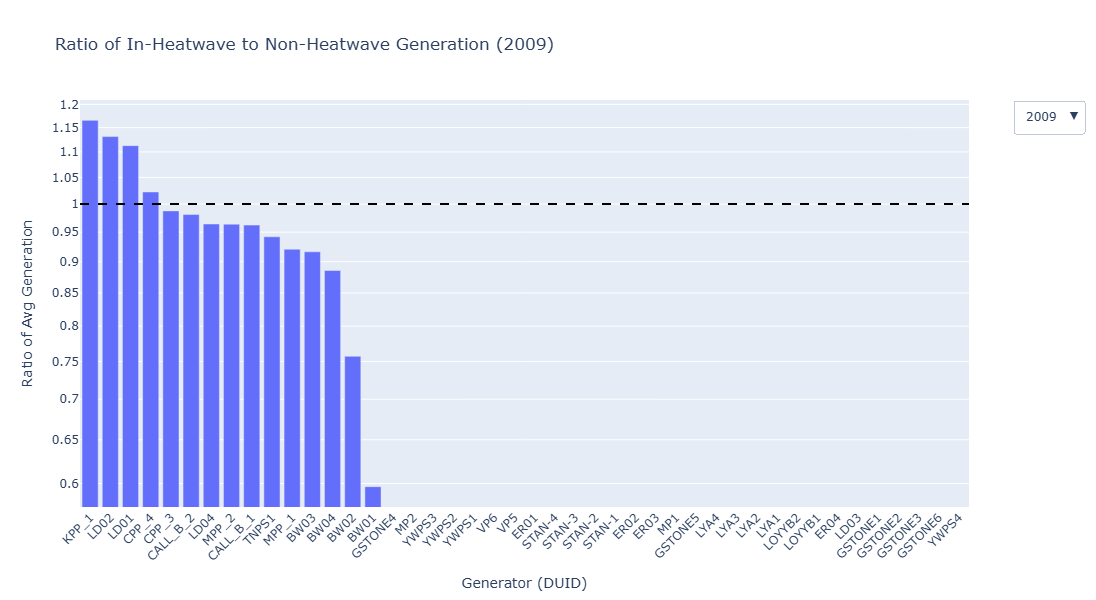

In [19]:
# Ensure time is datetime and extract year
dist_df['time'] = pd.to_datetime(dist_df['time'])
dist_df['year'] = dist_df['time'].dt.year

# Pivot table to get average generation per DUID/year per EHF_flag
avg_output = dist_df.pivot_table(
    index=['DUID', 'year'],
    columns='EHF_flag',
    values='TOTALMWh',
    aggfunc='mean',
    fill_value=0  # ensures both 0 and 1 exist even if missing
).reset_index()

# Rename columns for clarity
avg_output = avg_output.rename(columns={0:'avg_non_hw', 1:'avg_hw'})

# Compute difference and ratio
avg_output['diff'] = avg_output['avg_hw'] - avg_output['avg_non_hw']
# Avoid division by zero
avg_output['ratio'] = avg_output.apply(lambda row: row['avg_hw']/row['avg_non_hw'] if row['avg_non_hw'] != 0 else None, axis=1)

# Merge fuel type info
fuel_map = gen_info[['DUID', 'fuel_source_primary']].drop_duplicates()
avg_output = avg_output.merge(fuel_map, on='DUID', how='left')

# Inspect
print(avg_output.head())


years = sorted(avg_output['year'].unique())

fig = go.Figure()

# Add one bar chart per year
for i, year in enumerate(years):
    df_year = avg_output[avg_output['year'] == year].sort_values('ratio', ascending=False)

    fuel_types = df_year['fuel_source_primary'].unique()
    color_palette = px.colors.qualitative.Plotly
    color_map = {fuel: color_palette[j % len(color_palette)] for j, fuel in enumerate(fuel_types)}
    bar_colors = df_year['fuel_source_primary'].map(color_map)

    fig.add_trace(go.Bar(
        x=df_year['DUID'],
        y=df_year['ratio'],
        marker_color=bar_colors,
        customdata=df_year['fuel_source_primary'],
        hovertemplate='<b>DUID:</b> %{x}<br>Ratio: %{y}<br>Fuel: %{customdata}<extra></extra>',
        showlegend=False,
        visible=(i == 0)
    ))

# Dropdown buttons
buttons = []
for i, year in enumerate(years):
    visible = [False] * len(years)
    visible[i] = True
    buttons.append(dict(
        label=str(year),
        method="update",
        args=[{"visible": visible},
              {"title": f"Ratio of In-Heatwave to Non-Heatwave Generation ({year})"}]
    ))

# Layout
fig.update_layout(
    title=f"Ratio of In-Heatwave to Non-Heatwave Generation ({years[0]})",
    xaxis=dict(tickangle=-45, title='Generator (DUID)'),
    yaxis_type='log',
    yaxis_title='Ratio of Avg Generation',
    legend_title_text='Fuel Source',
    height=600,
    shapes=[dict(
        type='line',
        xref='paper', x0=0, x1=1,
        yref='y', y0=1, y1=1,
        line=dict(color='black', width=2, dash='dash')
    )],
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        x=1.05, y=1,
        xanchor="left", yanchor="top"
    )]
)

fig.show()


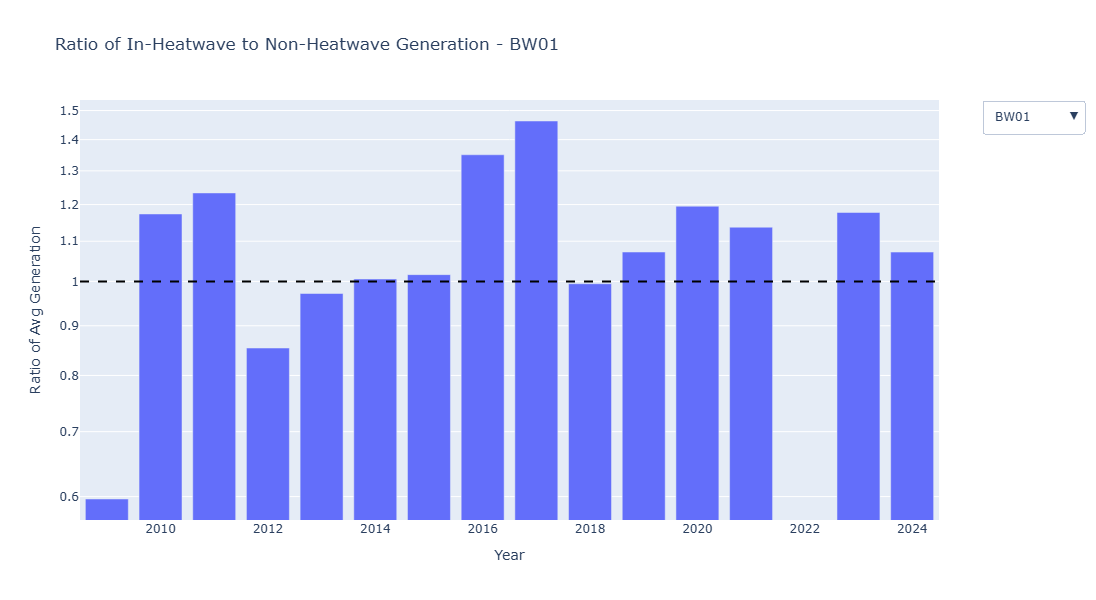

In [21]:
import plotly.graph_objects as go
import plotly.express as px

# Ensure avg_output exists and has: DUID, year, ratio, fuel_source_primary

duids = avg_output['DUID'].unique()

# Set up a consistent color map for fuel types
fuel_types = avg_output['fuel_source_primary'].unique()
color_palette = px.colors.qualitative.Plotly
color_map = {fuel: color_palette[i % len(color_palette)] for i, fuel in enumerate(fuel_types)}

fig = go.Figure()

# Add a bar trace per DUID
for i, duid in enumerate(duids):
    subset = avg_output[avg_output['DUID'] == duid]
    fig.add_trace(go.Bar(
        x=subset['year'],
        y=subset['ratio'],
        marker_color=subset['fuel_source_primary'].map(color_map),
        name=duid,
        customdata=subset['fuel_source_primary'],
        hovertemplate='<b>DUID:</b> %{name}<br>Year: %{x}<br>Ratio: %{y}<br>Fuel: %{customdata}<extra></extra>',
        visible=(i == 0)  # only show first DUID initially
    ))

# Create dropdown buttons for DUID selection
buttons = []
for i, duid in enumerate(duids):
    visible = [False] * len(duids)
    visible[i] = True
    buttons.append(dict(
        label=str(duid),
        method="update",
        args=[{"visible": visible},
              {"title": f"Ratio of In-Heatwave to Non-Heatwave Generation - {duid}"}]
    ))

# Update layout
fig.update_layout(
    title=f"Ratio of In-Heatwave to Non-Heatwave Generation - {duids[0]}",
    xaxis_title="Year",
    yaxis_title="Ratio of Avg Generation",
    yaxis_type="log",
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        x=1.05, y=1,
        xanchor="left",
        yanchor="top"
    )],
    height=600,
    shapes=[dict(
        type='line',
        xref='paper', x0=0, x1=1,
        yref='y', y0=1, y1=1,
        line=dict(color='black', width=2, dash='dash')
    )]
)

fig.show()


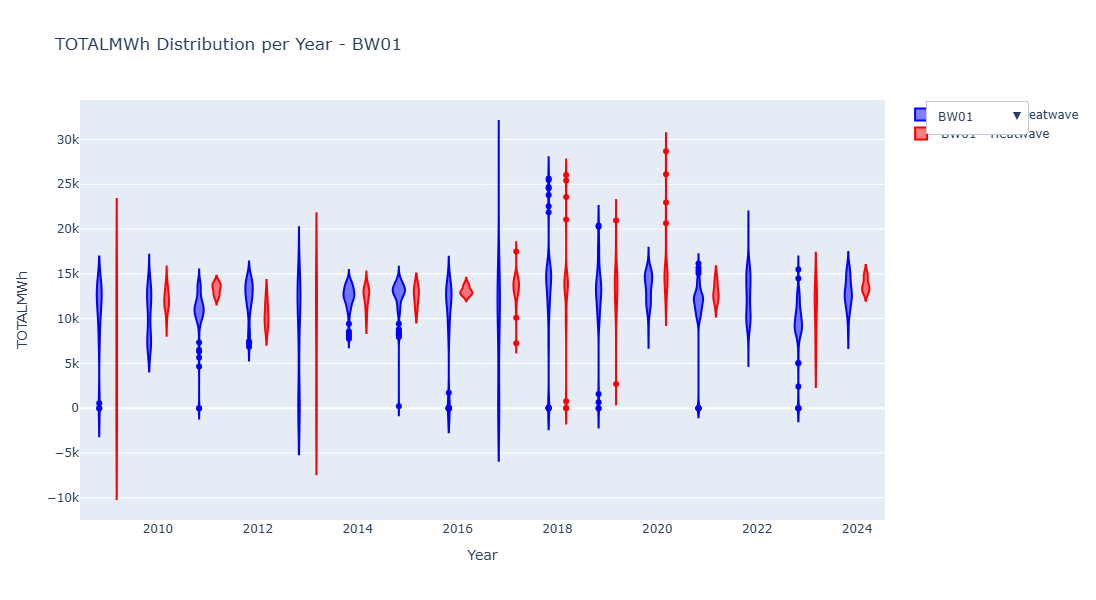

In [37]:
import plotly.graph_objects as go

# Ensure year column exists
df['year'] = pd.to_datetime(df['time']).dt.year

duids = df['DUID'].unique()

fig = go.Figure()

# Add one trace per DUID and EHF_flag
for i, duid in enumerate(duids):
    subset = df[df['DUID'] == duid]

    # Non-heatwave days
    fig.add_trace(go.Violin(
        x=subset[subset['EHF_flag']==0]['year'],
        y=subset[subset['EHF_flag']==0]['TOTALMWh'],
        name=f'{duid} - Non-Heatwave',
        marker_color='blue',
        visible=(i==0),
        box_visible=False
    ))

    # Heatwave days
    fig.add_trace(go.Violin(
        x=subset[subset['EHF_flag']==1]['year'],
        y=subset[subset['EHF_flag']==1]['TOTALMWh'],
        name=f'{duid} - Heatwave',
        marker_color='red',
        visible=(i==0),
        box_visible=False
    ))

# Create dropdown buttons
buttons = []
for i, duid in enumerate(duids):
    visible = [False] * (2*len(duids))  # 2 traces per DUID
    visible[2*i] = True
    visible[2*i + 1] = True
    buttons.append(dict(
        label=str(duid),
        method='update',
        args=[{"visible": visible},
              {"title": f"TOTALMWh Distribution per Year - {duid}"}]
    ))

# Update layout with dropdown
fig.update_layout(
    title=f"TOTALMWh Distribution per Year - {duids[0]}",
    xaxis_title="Year",
    yaxis_title="TOTALMWh",
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        x=1.05, y=1,
        xanchor="left", yanchor="top"
    )],
    height=600,
    violinmode='group'
)

fig.show()
